In [ ]:
!pip install matplotlib seaborn pandas numpy -q

In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Включаем стиль Seaborn (применяется и к Matplotlib)
sns.set_theme(style="darkgrid")
print("Библиотеки загружены!")

Библиотеки загружены!


In [ ]:
# Генерация банковского датасета
np.random.seed(42)
N = 2000

cities = ['Москва', 'Санкт-Петербург', 'Казань', 'Новосибирск', 'Екатеринбург']
names = ['Иван', 'Ольга', 'Дмитрий', 'Екатерина', 'Сергей', 'Анна', 'Алексей', 'Мария']

df = pd.DataFrame({
    'client_id': range(1001, 1001 + N),
    'name': np.random.choice(names, N),
    'city': np.random.choice(cities, N),
    'age': np.random.randint(21, 70, N),
    'income': np.random.normal(50000, 20000, N).astype(int),
    'loan_amount': np.random.normal(200000, 80000, N).astype(int),
    'credit_score': np.random.normal(650, 100, N).astype(int),
    'default': np.random.choice([0, 1], N, p=[0.9, 0.1])
})

# Добавляем аномалии для наглядности
df.loc[0, 'income'] = 500000
df.loc[1, 'loan_amount'] = 1000000
df.loc[2, 'age'] = 18

df['income'] = df['income'].clip(lower=0)
df['loan_amount'] = df['loan_amount'].clip(lower=0)

# Создаём возрастные группы для catplot
df['age_group'] = pd.cut(df['age'],
                         bins=[18, 30, 45, 70],
                         labels=['18-30', '30-45', '45-70'])

print(f"Датасет: {df.shape[0]} строк, {df.shape[1]} колонок")
df.head()

Датасет: 2000 строк, 9 колонок


,client_id,name,city,age,income,loan_amount,credit_score,default,age_group
0,1001,Алексей,Новосибирск,56,500000,224515,682,0,45-70
1,1002,Екатерина,Казань,28,48287,1000000,755,0,18-30
2,1003,Сергей,Екатеринбург,18,80152,144570,605,0,NaN
3,1004,Алексей,Москва,52,36156,195643,717,0,45-70
4,1005,Дмитрий,Екатеринбург,34,76160,165023,371,0,30-45


## 🎻 Violin plot — доход по городам

Сравним форму распределения доходов в разных городах. В отличие от boxplot, который показывает только квартили, violin plot рисует плотность распределения — мы видим, где данные «толще».

/tmp/ipykernel_8557/3457494111.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='city', y='income', data=df, palette='muted')


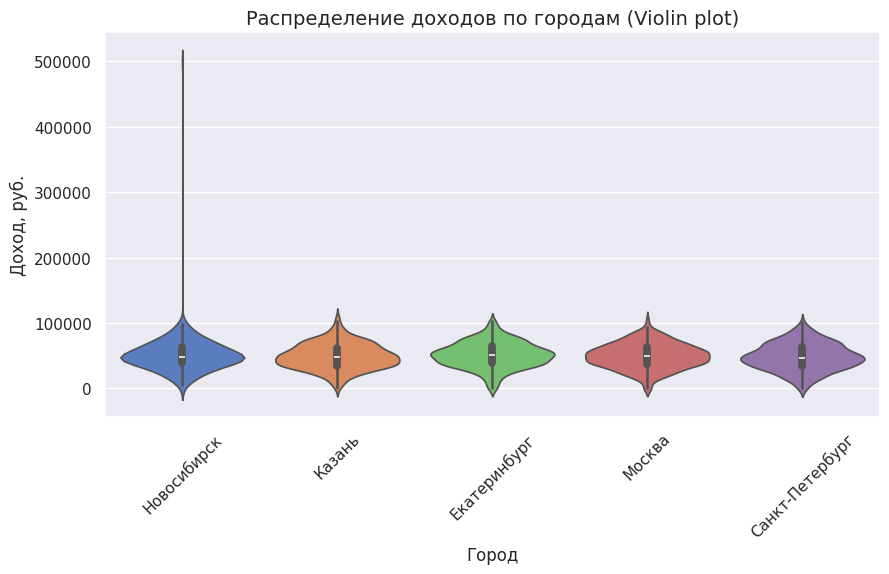

In [ ]:
#   sns.violinplot() — скрипичный график
#   x='city' — категории по горизонтали
#   y='income' — числовая переменная
#   data=df — наш DataFrame
#   palette='muted' — приглушённые цвета

plt.figure(figsize=(10, 5))
sns.violinplot(x='city', y='income', data=df, palette='muted')

# Добавляем точки median для наглядности (опционально)
# sns.pointplot добавит средние и доверительные интервалы
# но просто украсим график:
plt.title('Распределение доходов по городам (Violin plot)', fontsize=14)
plt.xlabel('Город')
plt.ylabel('Доход, руб.')
plt.xticks(rotation=45)
plt.show()

**ИНТЕРПРЕТАЦИЯ:**
- Широкие участки скрипки — самые частые доходы в этом городе.
- Узкие «хвосты» вверх — немногочисленные богатые клиенты.
- Cкрипка слегка шире в области низких доходов — возможно, там больше студентов.
- Виден длинный хвост вверх — несколько очень обеспеченных клиентов.

*Когда использовать:* когда важна форма распределения, а не только квартили. Хорош для сравнения 3–7 групп.

## 🔗 Joint plot — связь возраста и суммы кредита

Показывает scatter plot между двумя переменными и сбоку гистограммы каждой из них. Так видим и зависимость, и распределения по отдельности.

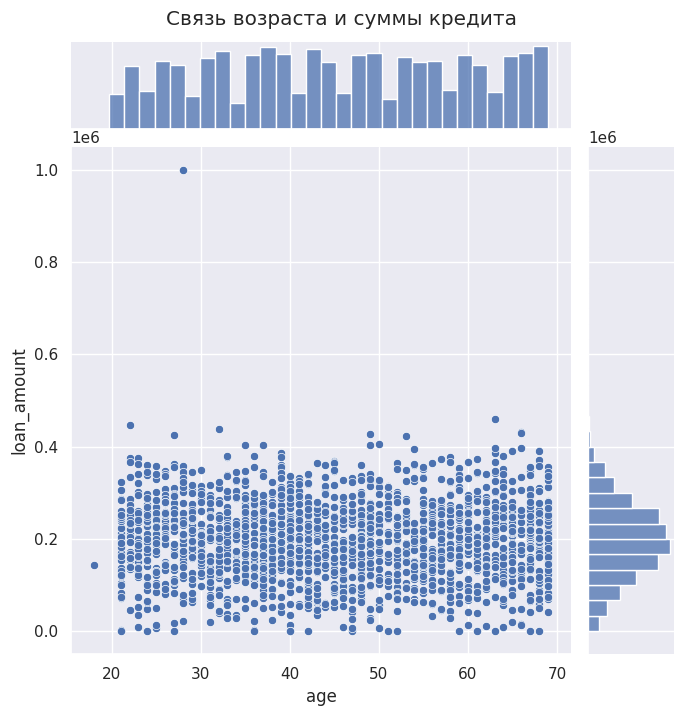

In [ ]:

#   sns.jointplot() — объединяет scatter с гистограммами
#   x='age', y='loan_amount' — переменные для осей
#   data=df — DataFrame
#   kind='scatter' — тип центрального графика
#   height=7 — размер фигуры
#   marginal_kws=dict(bins=30) — настройки для гистограмм


sns.jointplot(x='age', y='loan_amount', data=df,
              kind='scatter', height=7,
              marginal_kws=dict(bins=30))
plt.suptitle('Связь возраста и суммы кредита', y=1.02)
plt.show()

**ИНТЕРПРЕТАЦИЯ:**
- Основное облако точек не имеет ярко выраженного наклона — возраст не сильно влияет на сумму кредита.
- На верхней гистограмме видно, что большинству клиентов 25–60 лет.
- На правой гистограмме — суммы кредита концентрируются около 200 000 с длинным хвостом вправо.
- Пара выбросов заметна (огромный кредит у молодого и у возрастного клиента) — стоит проверить.

**Бонус:** попробуй `kind='reg'` — получишь линию регрессии.

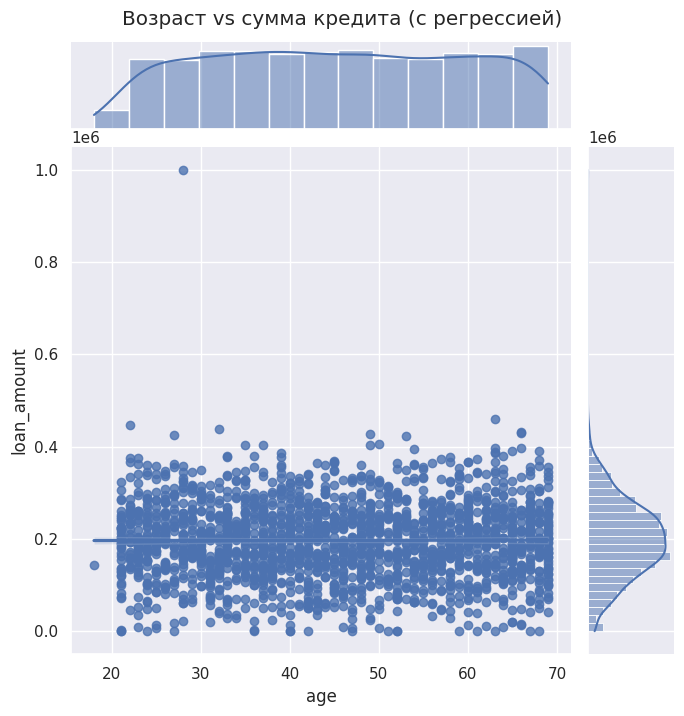

In [ ]:
# Joint plot с линией регрессии
sns.jointplot(x='age', y='loan_amount', data=df,
              kind='reg', height=7)
plt.suptitle('Возраст vs сумма кредита (с регрессией)', y=1.02)
plt.show()

## 🐝 Swarm plot — каждая точка на виду (на подвыборке)

Swarm plot хорош для небольших наборов данных, т.к. он раздвигает точки, исключая их перекрытие. Здесь возьмём первые 200 строк.

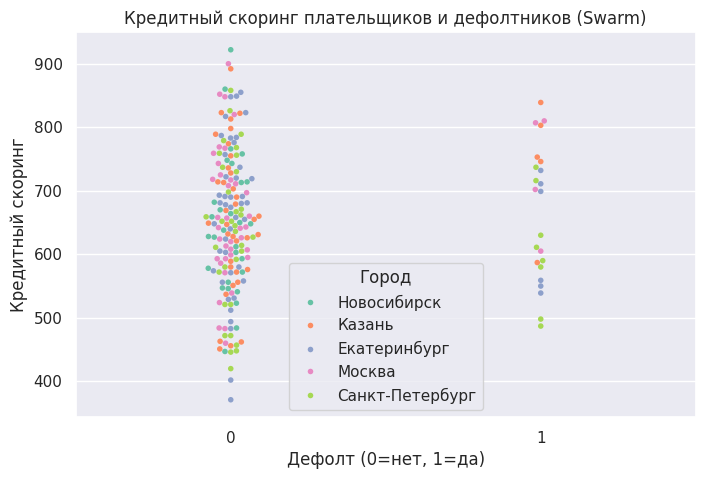

In [ ]:
#   sns.swarmplot() — точки без перекрытия
#   x='default' — группы (0 — плательщики, 1 — дефолт)
#   y='credit_score' — числовая переменная
#   data=subset — первые 200 строк для читаемости
#   hue='city' — разделение по городам (доп. цвет)
#   size=4 — размер точек

subset = df.head(200)
plt.figure(figsize=(8, 5))
sns.swarmplot(x='default', y='credit_score', data=subset,
              hue='city', size=4, palette='Set2')
plt.title('Кредитный скоринг плательщиков и дефолтников (Swarm)')
plt.xlabel('Дефолт (0=нет, 1=да)')
plt.ylabel('Кредитный скоринг')
plt.legend(title='Город')
plt.show()

**ИНТЕРПРЕТАЦИЯ:**
- У дефолтников (1) скоринг заметно ниже, основная масса точек скучена на уровне 500–600.
- Есть несколько дефолтников с высоким скорингом — вероятно, случайные просрочки.
- У плательщиков (0) разброс выше, много точек выше 700.
- Благодаря swarm точки не слипаются, мы видим отдельных клиентов.

*Когда использовать:* для малых выборок (до ~500 объектов), чтобы показать распределение внутри категорий.

## Catplot — универсальная фабрика графиков

Строим целую панель: сравниваем долю дефолтников (default) по городам и возрастным группам с помощью столбчатых диаграмм.

/tmp/ipykernel_8557/2880727514.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(x='city', y='default', data=df,


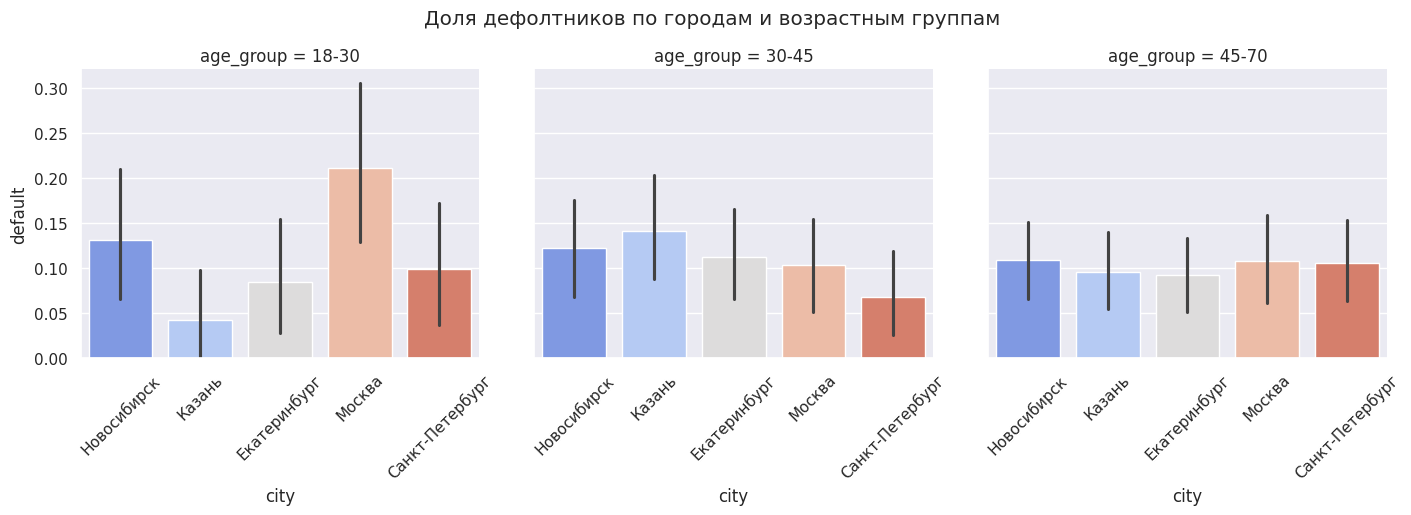

In [ ]:
#   sns.catplot() — многопанельный категориальный график
#   kind='bar' — столбчатая диаграмма со средним
#   x='city', y='default' — категории и целевая переменная
#   col='age_group' — разбиваем по возрастным группам
#   data=df — DataFrame
#   height=4, aspect=1.2 — размер панелей
#   ci='sd' — панель ошибок (стандартное отклонение)

g = sns.catplot(x='city', y='default', data=df,
                kind='bar', col='age_group',
                height=4, aspect=1.2, palette='coolwarm')
g.fig.suptitle('Доля дефолтников по городам и возрастным группам', y=1.05)
g.set_xticklabels(rotation=45)
plt.show()

**ИНТЕРПРЕТАЦИЯ:**
- По столбцам видно, что в группе 18-30 (левая панель) в некоторых городах дефолт заметно выше.
- В группе 45-70 (правая панель) доля дефолта снижается и более равномерна.
- Это позволяет точечно нацеливать риск-политику: например, ужесточить скоринг для молодых заёмщиков в Москве.

**Вариации kind:**
- `kind='violin'` — распределения;
- `kind='point'` — точки с соединительными линиями для трендов;
- `kind='count'` — подсчёт количества записей.

## 🎸 ТВОРЧЕСКОЕ ЗАДАНИЕ

1. Построй violin plot возраста по городам — есть ли города с более молодой аудиторией?
2. Используя joint plot с kind='kde', визуализируй связь дохода и кредитного скоринга.
3. С помощью swarm plot (на 150 точках) сравни доход плательщиков и дефолтников.
4. Создай catplot с kind='box' для суммы кредита по городам, сгруппировав по default (hue='default').
5. Для каждого графика напиши текстовую ячейку с выводами.

In [ ]:
# для твоего кода